In [1]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.0 MB/s eta 0:00:00a 0:00:01


In [2]:
import time
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from torch_geometric.nn import GATv2Conv, GlobalAttention, GINConv, PNAConv, GINEConv, GPSConv, global_add_pool, AttentiveFP
from torch.nn import BatchNorm1d,Sequential, Linear, ReLU, Dropout, Embedding, ModuleList
import torch.nn.functional as F
from torch_geometric.transforms import VirtualNode
from torch_geometric.nn.pool import global_add_pool, global_max_pool
from torch_geometric.utils import degree, to_scipy_sparse_matrix
import random
from torch_geometric.loader import DataLoader
import torch_geometric.transforms as T
from torch_geometric.nn.attention import PerformerAttention
from torch_geometric.data import Data
import scipy.sparse as sp
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from torch.optim.lr_scheduler import ReduceLROnPlateau
import re
import seaborn as sns
from typing import Any, Dict, Optional

In [3]:
SEED = 25
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [7]:
train_data = np.load('data/graphs/train_graphs.npz',allow_pickle=True)
keys = sorted(list(train_data.keys()))

In [8]:
print(f"Total number of keys in file {len(keys)}")
keys[:12]

Total number of keys in file 3631


['adj_100',
 'adj_1000',
 'adj_1001',
 'adj_1002',
 'adj_1003',
 'adj_1004',
 'adj_1005',
 'adj_1006',
 'adj_1007',
 'adj_1008',
 'adj_1009',
 'adj_1010']

In [9]:
num_graphs = len(keys) // 3
print(f"num of graphs = {num_graphs}")

num of graphs = 1210


In [10]:
indices = set()
re_keys = []
for k in keys:
    parts = k.split('_')
    if parts[0] in ['adj','x','y'] and parts[-1].isdigit():
        indices.add(int(parts[-1]))

s_idx = sorted(list(indices))
print(f"{len(s_idx)}")

1210


In [11]:
s_idx[:4]

[2, 3, 4, 5]

In [12]:
all_nodes = []
all_edges = []
all_labels = []
pyg_train_dataset = []
for i in s_idx:
    adj = train_data[f'adj_{i}']
    x = train_data[f'x_{i}']
    y = train_data[f'y_{i}']
    edge_idx = torch.tensor(np.array(np.nonzero(adj)),dtype=torch.long)
    data = Data(
        x = torch.tensor(x,dtype=torch.float),
        edge_index=edge_idx,
        y=torch.tensor(y,dtype=torch.float)
    )
    pyg_train_dataset.append(data)
    all_nodes.append(x.shape[0])
    all_edges.append(edge_idx.shape[0])
    all_labels.append(int(y))

/tmp/ipykernel_6514/3026872208.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  all_labels.append(int(y))


In [13]:
total_n = len(all_labels)
pos_n = sum(all_labels)
neg_n = total_n - pos_n

In [14]:
print(f"total graphs {total_n}")
print(f"class 1 = {pos_n} ({pos_n/total_n:.2%})")
print(f"class 0 = {neg_n} ({neg_n/total_n:.2%})")


total graphs 1210
class 1 = 480 (39.67%)
class 0 = 730 (60.33%)


In [15]:
print("average nodes per graph ", np.mean(all_nodes), "average edges per graph ",np.mean(all_edges))

average nodes per graph  33.60495867768595 average edges per graph  2.0


In [16]:
val_data = np.load('data/graphs/valid_graphs.npz',allow_pickle=True)
test_data = np.load('data/graphs/test_graphs.npz',allow_pickle=True)

In [17]:
def process_data(data, is_test=False):
    current_keys = sorted(list(data.keys()))
    indices = set()
    for k in current_keys:
        parts = k.split('_')
        if parts[0] in ['adj', 'x', 'y'] and parts[-1].isdigit():
            indices.add(int(parts[-1]))
    l = []
    sorted_idx = sorted(list(indices))
    for i in sorted_idx:
        adj = data[f'adj_{i}']
        x = data[f'x_{i}']
        y_key = f'y_{i}'
        if y_key in data:
            y = data[y_key]
            y_tensor = torch.tensor(y, dtype=torch.long).view(-1)
        else:
            y_tensor = torch.tensor([-1], dtype=torch.long)
        edge_idx = torch.tensor(np.array(np.nonzero(adj)), dtype=torch.long)
        d = Data(
            x=torch.tensor(x, dtype=torch.float),
            edge_index=edge_idx,
            y=y_tensor
        )
        l.append(d)
    return l

In [18]:
train_dataset = process_data(train_data)
val_dataset = process_data(val_data)
test_dataset  = process_data(test_data, is_test=True)

In [19]:
len(train_dataset),len(val_dataset),len(test_dataset)

(1210, 151, 152)

In [20]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [21]:
next(iter(train_loader))

DataBatch(x=[1092, 9], edge_index=[2, 2348], y=[32], batch=[1092], ptr=[33])

In [22]:
class GATv2(nn.Module):
    def __init__(self,in_channels,hidden_channels,out_channels,heads=4):
        super(GATv2,self).__init__()
        self.conv1 = GATv2Conv(in_channels,hidden_channels,heads=heads)
        self.bn1 = BatchNorm1d(hidden_channels * heads)
        self.conv2 = GATv2Conv(hidden_channels * heads,hidden_channels,heads=heads)
        self.bn2 = BatchNorm1d(hidden_channels * heads)
        self.conv3 = GATv2Conv(hidden_channels * heads,hidden_channels,heads=1)
        self.bn3 = BatchNorm1d(hidden_channels)
        self.gate_nn = Sequential(Linear(hidden_channels,1))
        self.pool = GlobalAttention(gate_nn=self.gate_nn)
        self.post_pool = Sequential(
            Linear(hidden_channels,hidden_channels),
            ReLU(),
            Dropout(0.5),
            Linear(hidden_channels,out_channels)
        )
    def forward(self,x,edge_index,batch):
        x = self.conv1(x,edge_index)
        x = self.bn1(x)
        x = F.elu(x)
        x = self.conv2(x,edge_index)
        x = self.bn2(x)
        x = F.elu(x)
        x = self.conv3(x,edge_index)
        x = self.bn3(x)
        x = F.elu(x)
        x = self.pool(x,batch)
        return self.post_pool(x)

In [23]:
model_gat = GATv2(in_channels=9,hidden_channels=64,out_channels=2)
model_gat = model_gat.to(device)
model_gat

/tmp/ipykernel_6514/1566590204.py:11: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=self.gate_nn)


GATv2(
  (conv1): GATv2Conv(9, 64, heads=4)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): GATv2Conv(256, 64, heads=4)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): GATv2Conv(256, 64, heads=1)
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (gate_nn): Sequential(
    (0): Linear(in_features=64, out_features=1, bias=True)
  )
  (pool): GlobalAttention(gate_nn=Sequential(
    (0): Linear(in_features=64, out_features=1, bias=True)
  ), nn=None)
  (post_pool): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)

In [24]:
optimizer_gat = torch.optim.AdamW(model_gat.parameters(),lr=0.0005,weight_decay=1e-3)
weights_gat = torch.tensor([1210/730, 1210/480]).to(device)
criterion_gat = torch.nn.CrossEntropyLoss(weight=weights_gat)
scheduler_gat = ReduceLROnPlateau(optimizer_gat, mode='max', factor=0.5, patience=10)

In [25]:
print("total num of params")
sum(p.numel() for p in model_gat.parameters())

total num of params


176259

In [26]:
def train(model,optimizer,criterion):
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x,data.edge_index,data.batch)
        loss = criterion(out, data.y.view(-1).long())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

In [27]:
@torch.no_grad()
def test(loader,model):
    model.eval()
    y_true, y_pred = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.batch)
        y_pred.append(out.argmax(dim=1).cpu())
        y_true.append(data.y.cpu())
    y_true = torch.cat(y_true).numpy()
    y_pred = torch.cat(y_pred).numpy()
    return f1_score(y_true, y_pred, average='macro')

In [28]:
epochs = 50
best_f1 = 0
history = {'train_loss':[],'val_f1':[]}
for epoch in range(1,epochs+1):
    loss = train(model_gat,optimizer_gat,criterion_gat)
    val_f1 = test(val_loader,model_gat)
    history['train_loss'].append(loss)
    history['val_f1'].append(val_f1)
    scheduler_gat.step(val_f1)
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model_gat.state_dict(), 'best_gat_model.pt')
    if epoch % 10 == 0:
        print(f'Epoch {epoch} Loss {loss:.4f} Val Macro F1 {val_f1:.4f} Best Macro F1  {best_f1:.4f}')

Epoch 10 Loss 0.4940 Val Macro F1 0.4523 Best Macro F1  0.5457
Epoch 20 Loss 0.3786 Val Macro F1 0.4379 Best Macro F1  0.5457
Epoch 30 Loss 0.3000 Val Macro F1 0.4679 Best Macro F1  0.5457
Epoch 40 Loss 0.2880 Val Macro F1 0.4766 Best Macro F1  0.5457
Epoch 50 Loss 0.2647 Val Macro F1 0.5114 Best Macro F1  0.5457


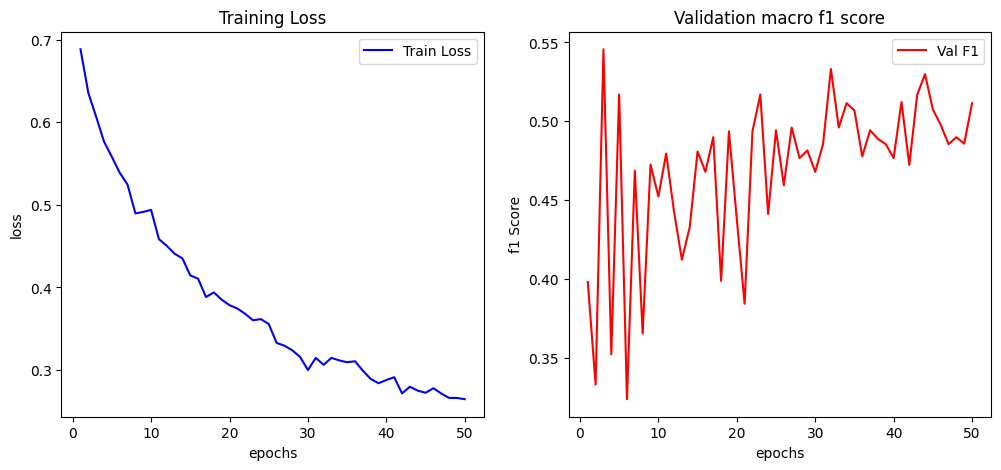

In [30]:
plt.figure(figsize = (12,5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(history['train_loss']) + 1), history['train_loss'], label='Train Loss', color='blue')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title("Training Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(history['val_f1']) + 1), history['val_f1'], label='Val F1', color='red')
plt.xlabel('epochs')
plt.ylabel('f1 Score')
plt.title("Validation macro f1 score")
plt.legend()
plt.show()

In [31]:
@torch.no_grad()
def eval(model,loader):
    model.eval()
    y_true = []
    y_pred = []
    for data in loader:
        data = data.to(device)
        out = model(data.x,data.edge_index,data.batch)
        pred = out.argmax(dim=1)
        y_true.extend(data.y.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())
    print("classification report")
    print(classification_report(y_true,y_pred,target_names=['0','1']))
    cm = confusion_matrix(y_true,y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm,annot=True,cmap='Blues',xticklabels=['0','1'],yticklabels=['0','1'])
    plt.title('Confusion matrix')
    plt.ylabel("Actual label")
    plt.xlabel('Predicted label')
    plt.show()

In [32]:
model_gat.load_state_dict(torch.load('best_gat_model.pt'))

<All keys matched successfully>

classification report
              precision    recall  f1-score   support

           0       0.22      0.62      0.33        21
           1       0.91      0.65      0.76       130

    accuracy                           0.65       151
   macro avg       0.57      0.64      0.55       151
weighted avg       0.82      0.65      0.70       151



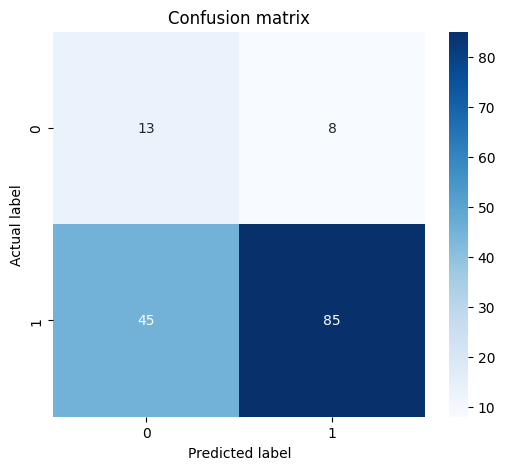

In [33]:
eval(model_gat,val_loader)

# GIN

In [34]:
class GIN(nn.Module):
    def __init__(self, in_channels=9, hidden_dim=128):
        super(GIN, self).__init__()
        def mlp(in_c, out_c):
            return nn.Sequential(
                nn.Linear(in_c, out_c),
                nn.BatchNorm1d(out_c),
                nn.ReLU(),
                nn.Linear(out_c, out_c)
            )
        self.conv1 = GINConv(mlp(in_channels, hidden_dim))
        self.conv2 = GINConv(mlp(hidden_dim, hidden_dim))
        self.conv3 = GINConv(mlp(hidden_dim, hidden_dim))
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))

        g_add = global_add_pool(x, batch)
        g_max = global_max_pool(x, batch)
        combined = torch.cat([g_add, g_max], dim=1)

        return self.classifier(combined)

In [35]:
class FocalLoss(nn.Module):
  def __init__(self,alpha=0.25,gamma=2.0,weight=None):
    super(FocalLoss,self).__init__()
    self.alpha = alpha
    self.gamma = gamma
    self.weight = weight
  def forward(self,inputs, targets):
    ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.weight)
    pt = torch.exp(-ce_loss)
    focal_loss = (self.alpha * (1 - pt)**self.gamma * ce_loss).mean()
    return focal_loss


In [36]:
model_gin = GIN(9).to(device)
optimizer_gin = torch.optim.AdamW(model_gin.parameters(), lr=0.001, weight_decay=1e-4)
scheduler_gin = ReduceLROnPlateau(optimizer_gin, mode='max', factor=0.5, patience=10)
weights_gin = torch.tensor([1210/730, 1210/480]).to(device)
#criterion_gin = torch.nn.CrossEntropyLoss(weight=weights_gin)
criterion_gin = FocalLoss(alpha=0.35,gamma=2.0,weight=weights_gin)

In [37]:
epochs = 100
best_f1 = 0
history = {'train_loss':[],'val_f1':[]}
for epoch in range(1,epochs):
    loss = train(model_gin,optimizer_gin,criterion_gin)
    val_f1 = test(val_loader,model_gin)
    history['train_loss'].append(loss)
    history['val_f1'].append(val_f1)
    scheduler_gin.step(val_f1)
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model_gin.state_dict(), 'best_gin_model.pt')
    if epoch % 10 == 0:
        print(f'Epoch {epoch} Loss {loss:.4f} Val Macro F1 {val_f1:.4f} Best Macro F1  {best_f1:.4f}')

/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` 

Epoch 10 Loss 0.1583 Val Macro F1 0.4319 Best Macro F1  0.5381


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` 

Epoch 20 Loss 0.1364 Val Macro F1 0.5732 Best Macro F1  0.5743


...

/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` 

Epoch 80 Loss 0.0410 Val Macro F1 0.5506 Best Macro F1  0.6686


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` 

Epoch 90 Loss 0.0307 Val Macro F1 0.5431 Best Macro F1  0.6686


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` 

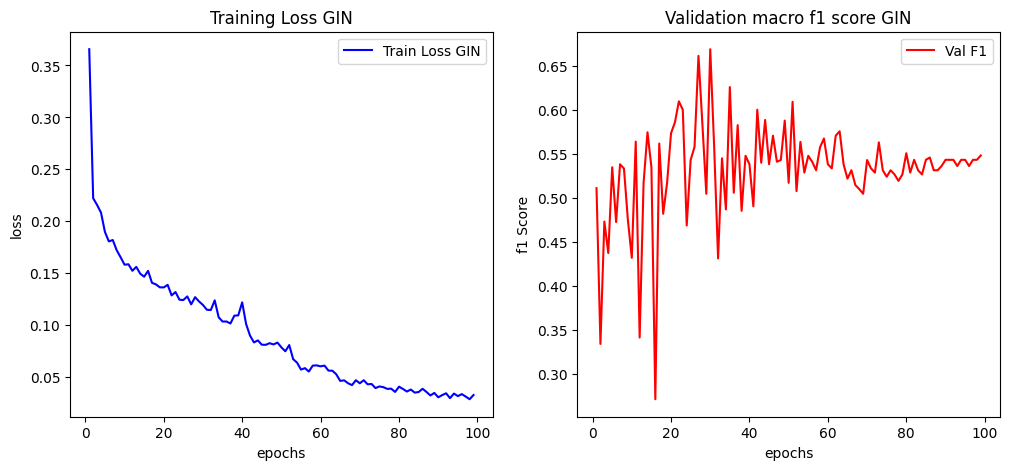

In [39]:
plt.figure(figsize = (12,5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(history['train_loss']) + 1), history['train_loss'], label='Train Loss GIN', color='blue')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title("Training Loss GIN")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(history['val_f1']) + 1), history['val_f1'], label='Val F1', color='red')
plt.xlabel('epochs')
plt.ylabel('f1 Score')
plt.title("Validation macro f1 score GIN")
plt.legend()
plt.show()

In [40]:
model_gin.load_state_dict(torch.load('best_gin_model.pt'))

<All keys matched successfully>

classification report
              precision    recall  f1-score   support

           0       0.54      0.33      0.41        21
           1       0.90      0.95      0.93       130

    accuracy                           0.87       151
   macro avg       0.72      0.64      0.67       151
weighted avg       0.85      0.87      0.85       151



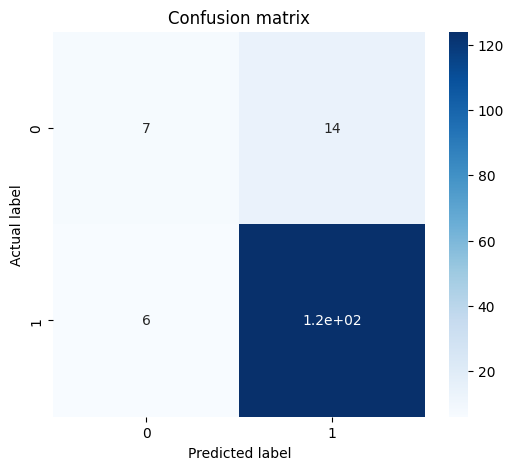

In [41]:
eval(model_gin,val_loader)

# Principal Neigbourhood Aggregation

In [42]:
def get_degree_hist(dataset):
  deg = []
  for data in dataset:
    d = degree(data.edge_index[0],num_nodes=data.num_nodes)
    deg.append(d)
  full_deg = torch.cat(deg).to(torch.long)
  return torch.bincount(full_deg)
deg = get_degree_hist(train_dataset)
deg

tensor([    0,  8030, 19475, 11764,  1393])

In [43]:
class PNA(nn.Module):
  def __init__(self,in_channels,hidden_dim,deg):
    super(PNA,self).__init__()
    self.vn_module = VirtualNode()
    agg = ['mean','min','max','std']
    scalers = ['identity','amplification','attenuation']
    self.conv1 = PNAConv(in_channels,hidden_dim,aggregators=agg, scalers=scalers, deg=deg, towers=4, pre_layers=1, post_layers=1)
    self.bn1= BatchNorm1d(hidden_dim)
    self.conv2 = PNAConv(hidden_dim,hidden_dim,aggregators=agg, scalers=scalers, deg=deg, towers=4, pre_layers=1, post_layers=1)
    self.bn2= BatchNorm1d(hidden_dim)
    self.conv3 = PNAConv(hidden_dim,hidden_dim,aggregators=agg, scalers=scalers, deg=deg, towers=4, pre_layers=1, post_layers=1)
    self.bn3= BatchNorm1d(hidden_dim)
    self.attn_nn = Sequential(Linear(hidden_dim,1))
    self.pool = GlobalAttention(gate_nn=self.attn_nn)

    self.classifier = Sequential(
        Linear(hidden_dim,hidden_dim),
        ReLU(),
        Dropout(0.4),
        Linear(hidden_dim,2)
    )

  def forward(self,x,edge_index,batch):
    x = self.conv1(x,edge_index)
    x = self.bn1(x)
    x = F.relu(x)
    x = self.conv2(x,edge_index)
    x = self.bn2(x)
    x = F.relu(x)
    x = self.conv3(x,edge_index)
    x = self.bn3(x)
    x = F.relu(x)
    x = self.pool(x,batch)
    return self.classifier(x)


In [44]:
model_pna = PNA(in_channels=9,hidden_dim=128,deg=deg).to(device)
optimizer_pna = torch.optim.AdamW(model_pna.parameters(),lr=0.001,weight_decay=1e-4)
scheduler_pna = ReduceLROnPlateau(optimizer_pna, mode='max', factor=0.5, patience=10)
weights_pna = torch.tensor([1210/730, 1210/480]).to(device)
criterion_pna = torch.nn.CrossEntropyLoss(weight=weights_pna)
# criterion_pna = FocalLoss(alpha=0.35, gamma=2.0, weight=weights_pna)

/tmp/ipykernel_6514/92314869.py:14: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=self.attn_nn)


In [45]:
epochs = 100
best_f1 = 0
history = {'train_loss':[],'val_f1':[]}
for epoch in range(1,epochs):
    loss = train(model_pna,optimizer_pna,criterion_pna)
    val_f1 = test(val_loader,model_pna)
    history['train_loss'].append(loss)
    history['val_f1'].append(val_f1)
    scheduler_pna.step(val_f1)
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model_pna.state_dict(), 'best_pna_model.pt')
    if epoch % 10 == 0:
        print(f'Epoch {epoch} Loss {loss:.4f} Val Macro F1 {val_f1:.4f} Best Macro F1  {best_f1:.4f}')

/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='min')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='min')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='min')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='min')` 

Epoch 10 Loss 0.4408 Val Macro F1 0.5172 Best Macro F1  0.6025


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='min')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='min')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='min')` 

Epoch 20 Loss 0.3446 Val Macro F1 0.4816 Best Macro F1  0.6339


...

/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='min')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='min')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='min')` 

Epoch 80 Loss 0.0794 Val Macro F1 0.5206 Best Macro F1  0.6686


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='min')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='min')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='min')` 

Epoch 90 Loss 0.0745 Val Macro F1 0.5160 Best Macro F1  0.6686


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='min')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='min')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='min')` 

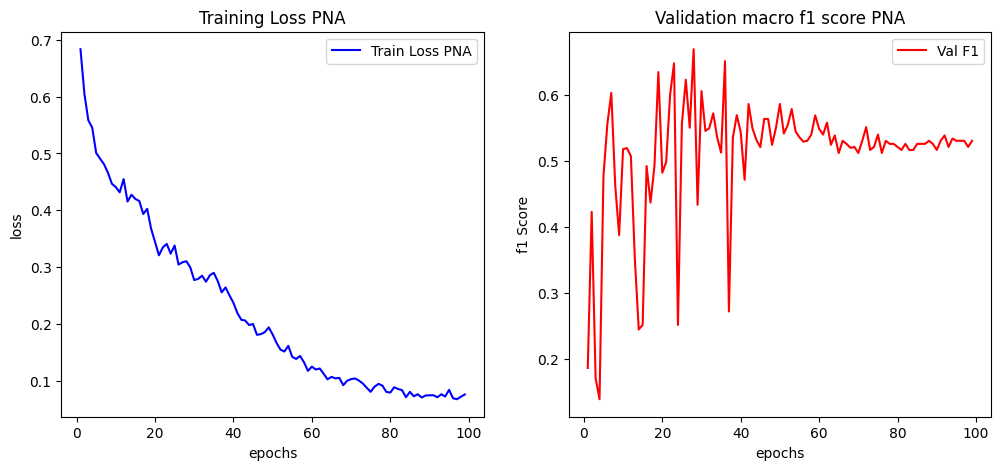

In [54]:
plt.figure(figsize = (12,5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(history['train_loss']) + 1), history['train_loss'], label='Train Loss PNA', color='blue')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title("Training Loss PNA")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(history['val_f1']) + 1), history['val_f1'], label='Val F1', color='red')
plt.xlabel('epochs')
plt.ylabel('f1 Score')
plt.title("Validation macro f1 score PNA")
plt.legend()
plt.show()

In [55]:
model_pna.load_state_dict(torch.load('best_pna_model.pt'))

<All keys matched successfully>

classification report
              precision    recall  f1-score   support

           0       0.54      0.33      0.41        21
           1       0.90      0.95      0.93       130

    accuracy                           0.87       151
   macro avg       0.72      0.64      0.67       151
weighted avg       0.85      0.87      0.85       151



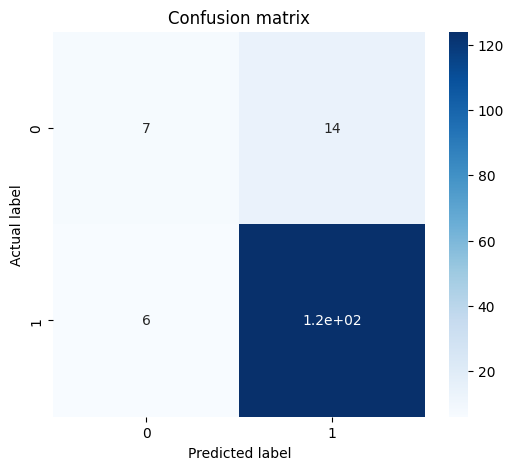

In [56]:
eval(model_pna,val_loader)

# Graph Transformer

---

refrence: https://pytorch-geometric.readthedocs.io/en/2.7.0/tutorial/graph_transformer.html







In [57]:
transform = T.AddRandomWalkPE(walk_length=20, attr_name='pe')

In [58]:
train_dataset_pe = [transform(d) for d in train_dataset]
val_dataset_pe = [transform(d) for d in val_dataset]
test_dataset_pe = [transform(d) for d in test_dataset]

In [59]:
train_loader_gt = DataLoader(train_dataset_pe, batch_size=32, shuffle=True)
val_loader_gt = DataLoader(val_dataset_pe, batch_size=32, shuffle=False)
test_loader_gt = DataLoader(test_dataset_pe, batch_size=32, shuffle=False)

In [60]:
class GPS(torch.nn.Module):
    def __init__(self, channels: int, pe_dim: int, num_layers: int, attn_type: str, attn_kwargs: Dict[str, Any]):
        super().__init__()

        self.node_emb = Linear(9, channels - pe_dim)
        self.pe_lin = Linear(20, pe_dim)
        self.pe_norm = BatchNorm1d(20)
        self.convs = ModuleList()
        for _ in range(num_layers):
            nn = Sequential(
                Linear(channels, channels),
                ReLU(),
                Linear(channels, channels),
            )
            conv = GPSConv(channels, GINConv(nn), heads=4, attn_type=attn_type, attn_kwargs=attn_kwargs)
            self.convs.append(conv)

        self.mlp = Sequential(
            Linear(channels, channels // 2),
            ReLU(),
            Dropout(0.3),
            Linear(channels // 2, 2),
        )

    def forward(self, x, pe, edge_index, batch):
        x_pe = self.pe_norm(pe)
        x = torch.cat((self.node_emb(x.float()), self.pe_lin(x_pe)), 1)
        for conv in self.convs:
            x = conv(x, edge_index, batch)
        x = global_add_pool(x, batch)
        return self.mlp(x)


In [61]:
attn_kwargs = {'dropout': 0.7}
model_gps = GPS(channels=64, pe_dim=8, num_layers=10, attn_type='multihead',
            attn_kwargs=attn_kwargs).to(device)
optimizer_gps = torch.optim.Adam(model_gps.parameters(), lr=0.001, weight_decay=5e-3)
scheduler_gps = ReduceLROnPlateau(optimizer_gps, mode='min', factor=0.5, patience=20,
                            min_lr=0.00001)
weights_gps = torch.tensor([1210/730, 1210/480]).to(device)
criterion_gps = torch.nn.CrossEntropyLoss(weight=weights_gps,label_smoothing=0.1)

In [63]:
def train_gps(model,optimizer,criterion):
    model.train()
    total_loss = 0
    for data in train_loader_gt:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x,data.pe,data.edge_index,data.batch)
        loss = criterion(out, data.y.view(-1).long())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader_gt)

In [64]:
@torch.no_grad()
def test_gps(loader,model):
    model.eval()
    y_true, y_pred = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x,data.pe, data.edge_index, data.batch)
        y_pred.append(out.argmax(dim=1).cpu())
        y_true.append(data.y.cpu())
    y_true = torch.cat(y_true).numpy()
    y_pred = torch.cat(y_pred).numpy()
    return f1_score(y_true, y_pred, average='macro')

In [65]:
epochs = 100
best_f1 = 0
history = {'train_loss':[],'val_f1':[]}
for epoch in range(1,epochs):
    loss = train_gps(model_gps,optimizer_gps,criterion_gps)
    val_f1 = test_gps(val_loader_gt,model_gps)
    history['train_loss'].append(loss)
    history['val_f1'].append(val_f1)
    scheduler_gps.step(val_f1)
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model_gps.state_dict(), 'best_gps_model.pt')
    if epoch % 10 == 0:
        print(f'Epoch {epoch} Loss {loss:.4f} Val Macro F1 {val_f1:.4f} Best Macro F1  {best_f1:.4f}')

Epoch 10 Loss 0.5614 Val Macro F1 0.4777 Best Macro F1  0.6107
Epoch 20 Loss 0.5115 Val Macro F1 0.4753 Best Macro F1  0.6107
Epoch 30 Loss 0.4884 Val Macro F1 0.5206 Best Macro F1  0.6107
Epoch 40 Loss 0.4685 Val Macro F1 0.4019 Best Macro F1  0.6107
Epoch 50 Loss 0.4397 Val Macro F1 0.4899 Best Macro F1  0.6107
Epoch 60 Loss 0.4364 Val Macro F1 0.5673 Best Macro F1  0.6107
Epoch 70 Loss 0.4159 Val Macro F1 0.5555 Best Macro F1  0.6107
Epoch 80 Loss 0.4228 Val Macro F1 0.4523 Best Macro F1  0.6107
Epoch 90 Loss 0.4113 Val Macro F1 0.4935 Best Macro F1  0.6107


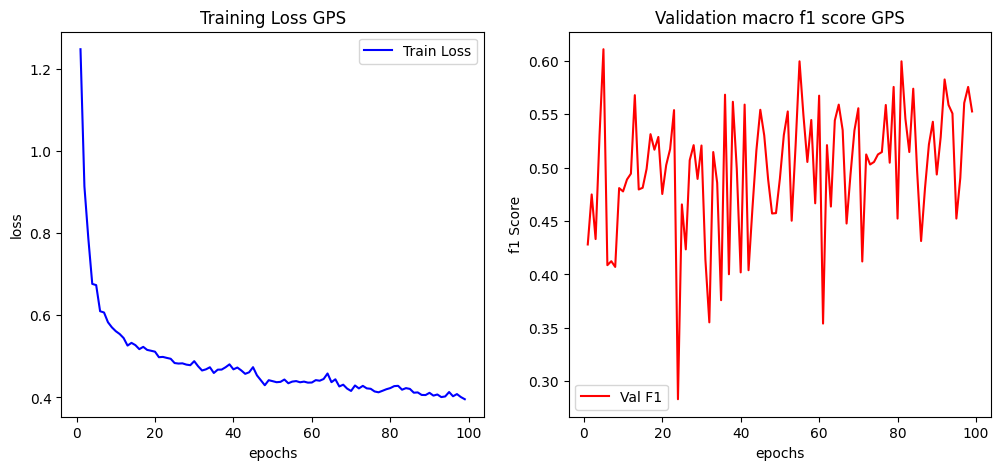

In [69]:
plt.figure(figsize = (12,5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(history['train_loss']) + 1), history['train_loss'], label='Train Loss', color='blue')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title("Training Loss GPS")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(history['val_f1']) + 1), history['val_f1'], label='Val F1', color='red')
plt.xlabel('epochs')
plt.ylabel('f1 Score')
plt.title("Validation macro f1 score GPS")
plt.legend()
plt.show()

In [70]:
@torch.no_grad()
def eval_gps(model,loader):
    model.eval()
    y_true = []
    y_pred = []
    for data in loader:
        data = data.to(device)
        out = model(data.x,data.pe,data.edge_index,data.batch)
        pred = out.argmax(dim=1)
        y_true.extend(data.y.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())
    print("classification report")
    print(classification_report(y_true,y_pred,target_names=['0','1']))
    cm = confusion_matrix(y_true,y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm,annot=True,cmap='Blues',xticklabels=['0','1'],yticklabels=['0','1'])
    plt.title('Confusion matrix')
    plt.ylabel("Actual label")
    plt.xlabel('Predicted label')
    plt.show()

classification report
              precision    recall  f1-score   support

           0       0.30      0.43      0.35        21
           1       0.90      0.84      0.87       130

    accuracy                           0.78       151
   macro avg       0.60      0.63      0.61       151
weighted avg       0.82      0.78      0.80       151



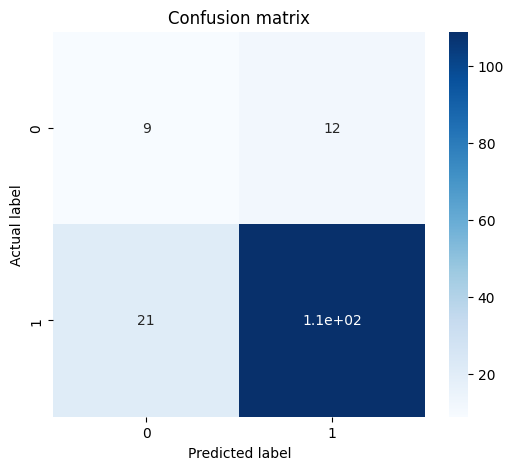

In [71]:
model_gps.load_state_dict(torch.load('best_gps_model.pt'))
eval_gps(model_gps,val_loader_gt)

# AttentiveFP

In [75]:
class AttentionFP(nn.Module):
    def __init__(self, in_channels, hidden_dim, num_layers=3, timesteps=2):
        super().__init__()
        self.attfp = AttentiveFP(
            in_channels=in_channels,
            hidden_channels=hidden_dim,
            out_channels=hidden_dim,
            edge_dim=1,
            num_layers=num_layers,
            num_timesteps=timesteps,
            dropout=0.2
        )
        self.classifier = Sequential(
            Linear(hidden_dim, hidden_dim),
            ReLU(),
            Dropout(0.4),
            Linear(hidden_dim, 2),
        )
    def forward(self, x, edge_index, batch):
        num_edges = edge_index.size(1)
        edge_attr = torch.zeros((num_edges, 1), device=x.device) 
        x = self.attfp(x, edge_index, edge_attr, batch)
        return self.classifier(x)

In [76]:
model_attnfp = AttentionFP(in_channels=9,hidden_dim=128,num_layers=3,timesteps=2).to(device)
optimizer_attnfp = torch.optim.AdamW(model_attnfp.parameters(),lr=0.001,weight_decay=1e-4)
scheduler_attnfp = ReduceLROnPlateau(optimizer_attnfp,mode='max',factor=0.5,patience=10)
weights_attnfp = torch.tensor([1210/730, 1210/480]).to(device)
criterion_attnfp = torch.nn.CrossEntropyLoss(weight=weights_attnfp)

In [77]:
epochs = 100
best_f1 = 0
history = {'train_loss':[], 'val_f1':[]}
for epoch in range(1, epochs):
    loss = train(model_attnfp, optimizer_attnfp, criterion_attnfp)
    val_f1 = test(val_loader, model_attnfp)
    history['train_loss'].append(loss)
    history['val_f1'].append(val_f1)
    scheduler_attnfp.step(val_f1)
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model_attnfp.state_dict(), 'best_attfp_model.pt')

    if epoch % 10 == 0:
        print(f'Epoch {epoch} Loss {loss:.4f} Val Macro F1 {val_f1:.4f} Best Macro F1 {best_f1:.4f}')

Epoch 10 Loss 0.6359 Val Macro F1 0.5316 Best Macro F1 0.5755
Epoch 20 Loss 0.4786 Val Macro F1 0.5623 Best Macro F1 0.5755
Epoch 30 Loss 0.4145 Val Macro F1 0.5333 Best Macro F1 0.5755
Epoch 40 Loss 0.3834 Val Macro F1 0.5477 Best Macro F1 0.5755
Epoch 50 Loss 0.3663 Val Macro F1 0.5480 Best Macro F1 0.5755
Epoch 60 Loss 0.3537 Val Macro F1 0.5525 Best Macro F1 0.5755
Epoch 70 Loss 0.3450 Val Macro F1 0.5623 Best Macro F1 0.5755
Epoch 80 Loss 0.3580 Val Macro F1 0.5623 Best Macro F1 0.5755
Epoch 90 Loss 0.3549 Val Macro F1 0.5623 Best Macro F1 0.5755


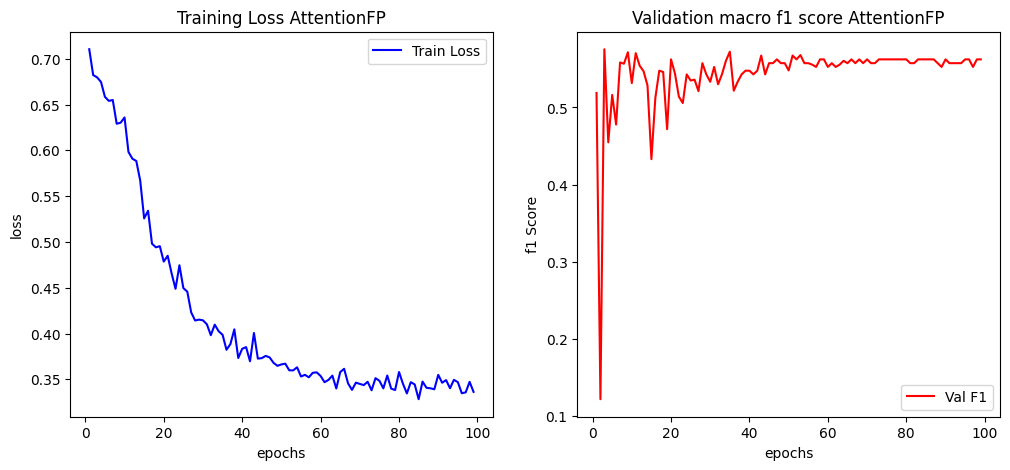

In [78]:
plt.figure(figsize = (12,5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(history['train_loss']) + 1), history['train_loss'], label='Train Loss', color='blue')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title("Training Loss AttentionFP")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(history['val_f1']) + 1), history['val_f1'], label='Val F1', color='red')
plt.xlabel('epochs')
plt.ylabel('f1 Score')
plt.title("Validation macro f1 score AttentionFP")
plt.legend()
plt.show()

classification report
              precision    recall  f1-score   support

           0       0.25      0.62      0.36        21
           1       0.92      0.70      0.79       130

    accuracy                           0.69       151
   macro avg       0.58      0.66      0.58       151
weighted avg       0.83      0.69      0.73       151



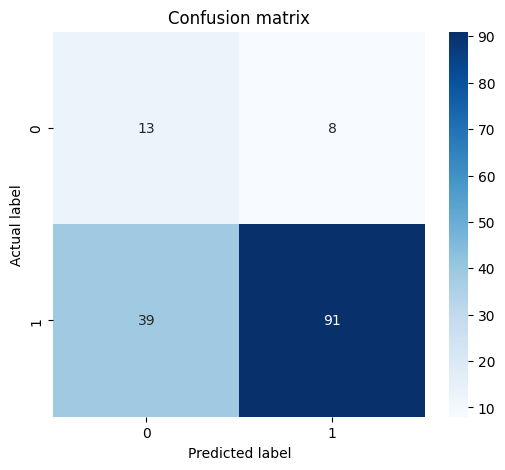

In [79]:
model_attnfp.load_state_dict(torch.load('best_attfp_model.pt'))
eval(model_attnfp,val_loader)

# GINE

In [85]:
class GINE(nn.Module):

    def __init__(self, in_channels=9, hidden_dim=128):
        super(GINE, self).__init__()

        def mlp(in_c, out_c):
            return nn.Sequential(
                nn.Linear(in_c, out_c),
                nn.BatchNorm1d(out_c),
                nn.ReLU(),
                nn.Linear(out_c, out_c)
            )

        self.conv1 = GINEConv(mlp(in_channels, hidden_dim), edge_dim=1)
        self.conv2 = GINEConv(mlp(hidden_dim, hidden_dim), edge_dim=1)
        self.conv3 = GINEConv(mlp(hidden_dim, hidden_dim), edge_dim=1)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, x, edge_index, batch):

        num_edges = edge_index.size(1)
        edge_attr = torch.zeros((num_edges,1), device=x.device)

        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        x = F.relu(self.conv3(x, edge_index, edge_attr))

        g_add = global_add_pool(x, batch)
        g_max = global_max_pool(x, batch)

        x = torch.cat([g_add, g_max], dim=1)

        return self.classifier(x)

In [86]:
model_gine = GINE(9).to(device)

optimizer_gine = torch.optim.AdamW(
    model_gine.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler_gine = ReduceLROnPlateau(
    optimizer_gine,
    mode='max',
    factor=0.5,
    patience=10
)

weights_gine = torch.tensor([1210/730, 1210/480]).to(device)

criterion_gine = FocalLoss(alpha=0.35, gamma=2.0, weight=weights_gine)

In [87]:
epochs = 100
best_f1 = 0
history = {'train_loss':[], 'val_f1':[]}
for epoch in range(1, epochs):
    loss = train(model_gine, optimizer_gine, criterion_gine)
    val_f1 = test(val_loader, model_gine)
    history['train_loss'].append(loss)
    history['val_f1'].append(val_f1)
    scheduler_gine.step(val_f1)
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model_gine.state_dict(), 'best_gine_model.pt')

    if epoch % 10 == 0:
        print(f'Epoch {epoch} Loss {loss:.4f} Val Macro F1 {val_f1:.4f} Best Macro F1 {best_f1:.4f}')

/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` 

Epoch 10 Loss 0.1680 Val Macro F1 0.5897 Best Macro F1 0.5897


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` 

Epoch 20 Loss 0.1456 Val Macro F1 0.5489 Best Macro F1 0.6155


...

/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` 

Epoch 80 Loss 0.0542 Val Macro F1 0.5076 Best Macro F1 0.6666


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` 

Epoch 90 Loss 0.0567 Val Macro F1 0.5239 Best Macro F1 0.6666


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` 

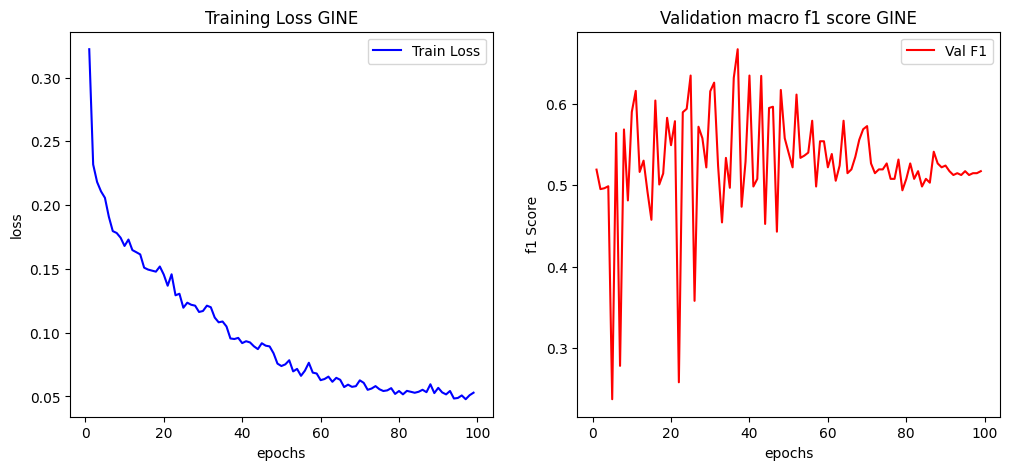

In [90]:
plt.figure(figsize = (12,5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(history['train_loss']) + 1), history['train_loss'], label='Train Loss', color='blue')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title("Training Loss GINE")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(history['val_f1']) + 1), history['val_f1'], label='Val F1', color='red')
plt.xlabel('epochs')
plt.ylabel('f1 Score')
plt.title("Validation macro f1 score GINE")
plt.legend()
plt.show()

classification report
              precision    recall  f1-score   support

           0       0.40      0.48      0.43        21
           1       0.91      0.88      0.90       130

    accuracy                           0.83       151
   macro avg       0.66      0.68      0.67       151
weighted avg       0.84      0.83      0.83       151



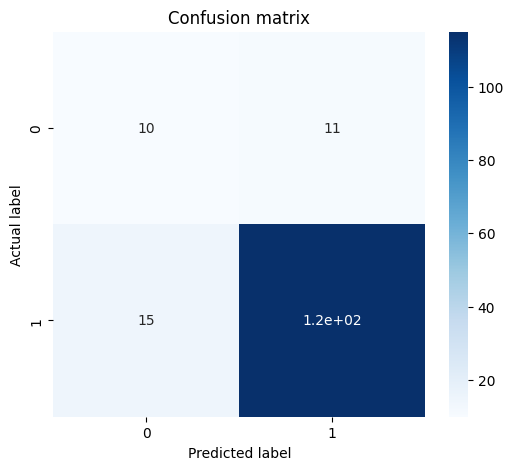

In [91]:
model_gine.load_state_dict(torch.load('best_gine_model.pt'))
eval(model_gine,val_loader)

# Ensembles

In [110]:
model_attnfp.load_state_dict(torch.load('best_attfp_model.pt'))
model_gin.load_state_dict(torch.load('best_gin_model.pt'))
model_gine.load_state_dict(torch.load('best_gine_model.pt'))
model_pna.load_state_dict(torch.load('best_pna_model.pt'))
model_gat.load_state_dict(torch.load('best_gat_model.pt'))

<All keys matched successfully>

In [111]:
models = [model_attnfp, model_gin, model_gine, model_pna, model_gat]
for m in models:
    m.eval()

In [127]:
all_logits = []
all_labels = []
start_time = time.time()
with torch.no_grad():
    for data in val_loader:
        data = data.to(device)
        logits_sum = 0
        for model in models:
            out = model(data.x, data.edge_index, data.batch)
            logits_sum += out
        avg_logits = logits_sum / len(models)

        all_logits.append(avg_logits.cpu())
        all_labels.append(data.y.cpu())

end_time = time.time()
total_time = end_time - start_time
logits = torch.cat(all_logits)
y_true = torch.cat(all_labels).numpy()
probs = F.softmax(logits, dim=1)[:,1].numpy()
best_f1 = 0
best_threshold = 0

for t in np.arange(0.1, 0.9, 0.01):
    preds = (probs > t).astype(int)
    f1 = f1_score(y_true, preds, average="macro")

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t
final_preds = (probs > best_threshold).astype(int)


In [130]:
print(classification_report(y_true, final_preds))

              precision    recall  f1-score   support

           0       0.67      0.38      0.48        21
           1       0.91      0.97      0.94       130

    accuracy                           0.89       151
   macro avg       0.79      0.68      0.71       151
weighted avg       0.87      0.89      0.87       151



In [114]:
test_loader

In [117]:
test_logits = []
with torch.no_grad():
    for data in test_loader:
        data = data.to(device)

        logits_sum = 0
        for model in models:
            out = model(data.x, data.edge_index, data.batch)
            logits_sum += out

        avg_logits = logits_sum / len(models)

        test_logits.append(avg_logits.cpu())

logits_test = torch.cat(test_logits)

In [118]:
probs_test = F.softmax(logits_test, dim=1)[:,1].numpy()

In [120]:
test_preds = (probs_test > best_threshold).astype(int)

In [121]:
test_preds

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0])

In [122]:
test_ids = pd.read_csv("data/test.csv", header=None)
test_ids.columns = ["id"]
print(test_ids.head())

   id
0   0
1   1
2   6
3   7
4   8


In [123]:
submission = pd.DataFrame({
    "id": test_ids["id"],
    "target": test_preds
})
submission.to_csv("submission.csv", index=False)

In [124]:
submission["target"].value_counts()

target
1    106
0     46
Name: count, dtype: int64

In [136]:
len(pd.read_csv('submission_faran.csv'))

152

In [125]:
 sum(sum(p.numel() for p in m.parameters()) for m in models)

1699146

In [137]:
print(f"Inference time = {(total_time * 1000)/152}")

Inference time = 0.8113509730288857
